In [1]:
import numpy as np #For the array functions
import tensorflow as tf
from tensorflow import keras #we will only be using tensorflow as a backend, so we will import keras via their implementation
from tensorflow.keras import layers #we will use the readable keras implementation of the conv/reccurent layers

import io
import os
import pandas as pd


In [12]:
depthDF = pd.read_csv('./Subject1.txt')

poses = ["Punch_VFR","Punch_VFL","One_VFR","One_VFL","Two_VFR","Two_VFL","Three_VFR","Three_VFL","Four_VFR","Four_VFL","Five_VFR","Five_VFL","Six_VFR","Six_VFL","Seven_VFR","Seven_VFL","Eight_VFR","Eight_VFL","Nine_VFR","Nine_VFL","Span_VFR","Span_VFL","Horiz_HBL","Horiz_HFL","Horiz_HBR","Horiz_HFR","Collab","XSign","TimeOut"]

posesDF = depthDF.drop(['rgb','depth'], axis = 'columns')
posesCols = [col for col in depthDF.columns if col not in ['rgb', 'depth']]

finalColumns = ['depth', 'coordinates', 'label']

#label = [-1] * len(file)
#file['label'] = label

for index, row in depthDF.iterrows():
    filledCols = []
    #for col in posesCols:
    for col_index, col_name in enumerate(posesCols):    
        if row[col_name] != "[0 0 0 0]":
            depthDF.loc[index, 'coordinates'] = row[col_name]
            depthDF.loc[index, 'label'] = col_index
            filledCols.append(row[col_name])

    if len(filledCols) != 1:
        depthDF = depthDF.drop(index, axis='rows')

for col_name in depthDF.columns:
    if(col_name not in finalColumns):
        depthDF = depthDF.drop(col_name, axis='columns')

print(depthDF)

                                 depth        coordinates  label
5     ..\Subject2\Depth\3791_depth.png  [412 283 103 109]   27.0
7     ..\Subject2\Depth\3789_depth.png  [410 281 105 111]   27.0
8     ..\Subject2\Depth\3737_depth.png   [416 284 97 109]   27.0
10    ..\Subject2\Depth\5145_depth.png  [413 284 103 109]   27.0
13    ..\Subject2\Depth\3813_depth.png  [415 288 101 111]   27.0
...                                ...                ...    ...
2354  ..\Subject2\Depth\3451_depth.png    [408 358 96 59]   26.0
2364  ..\Subject2\Depth\3429_depth.png   [394 349 100 67]   26.0
2367  ..\Subject2\Depth\3741_depth.png   [416 282 97 111]   27.0
2370  ..\Subject2\Depth\3485_depth.png    [415 357 89 53]   26.0
2393  ..\Subject2\Depth\3584_depth.png   [411 277 95 104]   28.0

[450 rows x 3 columns]


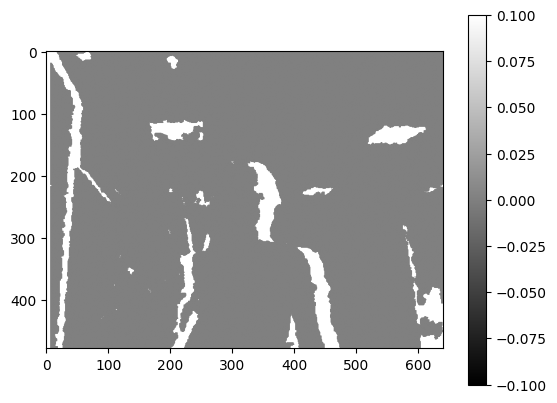

In [ ]:
depthMap = pd.read_csv('5.txt')
#depthArray = depthArray.reshape((480, 640))

import matplotlib.pyplot as plt

#for counter in range(len(depthMap)):
#    depthMap[counter] = [9000 if i > 1500 else i for i in depthMap[counter]]
    #if depthMap[counter] > 1000:
    #    depthMap[counter] = 9000

depth = np.array(depthMap, dtype=np.float32)
depth[depth == 0] = np.nan
depth[depth > 1500] = 0

min_depth = np.nanmin(depth)
hand_mask = (depth > min_depth) & (depth < min_depth + 250)



segmented_depth = depth * hand_mask

plt.imshow(segmented_depth, cmap='gray')
plt.colorbar()
plt.show()